In [7]:
import tensorflow as tf
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt


In [8]:
datasetPath = Path("../dataset/data_wound_seg_256")

In [9]:
train_image = datasetPath/"train_images"
train_mask = datasetPath/"train_masks"

In [10]:
train_image_path = sorted(train_image.glob("*.png"))
train_mask_path = sorted(train_mask.glob("*.png"))

In [11]:
print(len(train_image_path))
print(len(train_mask_path))

2208
2208


In [15]:
image = np.array(Image.open(train_image_path[0]))
mask = np.array(Image.open(train_mask_path[0]))

In [ ]:
image.shape


(256, 256, 3)

In [18]:
mask.shape

(256, 256, 3)

In [19]:
image.dtype

dtype('uint8')

In [20]:
mask.dtype

dtype('uint8')

In [21]:
np.unique(mask)

array([  0, 255], dtype=uint8)

In [22]:
image = image.astype(np.float32) /255.0

In [25]:
image.max()
image.min()

0.0

In [26]:
mask = mask.astype(np.float32) / 255.0

In [28]:
mask.max()
mask.min()

0.0

In [29]:
print(np.unique(mask))

[0. 1.]


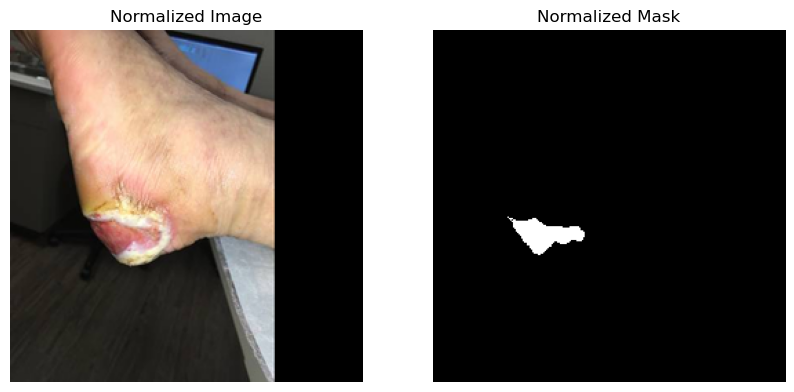

In [30]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Normalized Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Normalized Mask")
plt.axis("off")

plt.show()

In [33]:
def imageLoader (image_path, mask_path):
    image = np.array(Image.open(image_path), dtype=np.float32)/255.0
    mask - np.array(Image.open(mask_path), dtype=np.float32)/255.0
    return image,mask

In [35]:
image, mask = imageLoader(train_image_path[1], train_mask_path[1])

In [36]:
image.shape

(256, 256, 3)

In [37]:
mask.shape

(256, 256, 3)

In [38]:
print(image.shape)
print(mask.shape)

print(image.dtype)
print(mask.dtype)

print(image.min(), image.max())

print(np.unique(mask))

(256, 256, 3)
(256, 256, 3)
float32
float32
0.0 1.0
[0. 1.]


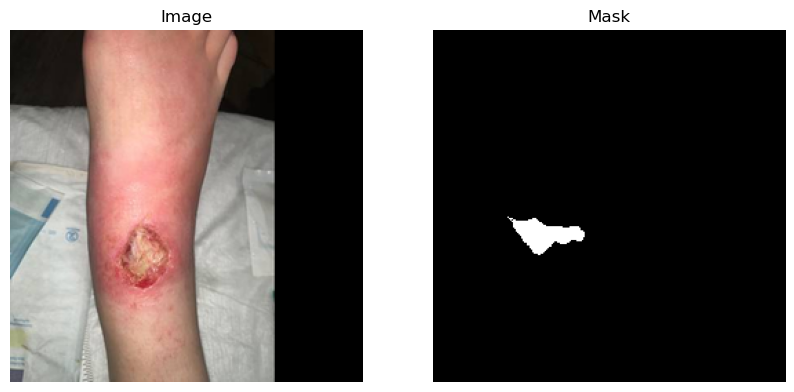

In [39]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.show()

In [41]:
train_image_path = [str(path) for path in train_image_path]
train_mask_path = [str(path) for path in train_mask_path]

In [43]:
train_dataset = tf.data.Dataset.from_tensor_slices(
    (train_image_path, train_mask_path)
)

In [44]:
print(type(train_image_path[0]))

<class 'str'>


In [ ]:
def load_image_masks(imagePath, mask_path):
    image = tf.io.read_file(imagePath)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.convert_image_dtype(image, tf.float32)

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.imageImage.convert_image_dtype(mask, tf.float32)

    image.set_shape([256, 256, 3])
    mask.set_shape([256, 256, 1])

    return image, mask

In [46]:
train_dataset = train_dataset.map(load_image_masks)

In [47]:
for image,mask in train_dataset.take(1):
    print(image.shape)
    print(mask.shape)

(256, 256, 3)
(256, 256, 1)


In [48]:
train_dataset = train_dataset.shuffle(2208)
train_dataset = train_dataset.batch(8)
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)

In [49]:
for image, mask in train_dataset.take(1):
    print(image.shape)
    print(mask.shape)

(8, 256, 256, 3)
(8, 256, 256, 1)


In [50]:
BUFFER_SIZE  = len(train_image_path)

In [52]:
train_dataset = train_dataset.shuffle(BUFFER_SIZE)

In [53]:
BATCH_SIZE = 8
train_dataset = train_dataset.batch(BATCH_SIZE)

In [54]:
train_dataset= train_dataset.prefetch(tf.data.AUTOTUNE)

In [55]:
for images, masks in train_dataset.take(1):
    print(images.shape)
    print(masks.shape)

(8, 8, 256, 256, 3)
(8, 8, 256, 256, 1)


2026-08-04 00:53:57.632242: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 67108864 bytes after encountering the first element of size 67108864 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
2026-08-04 00:53:57.632311: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 67108864 bytes after encountering the first element of size 67108864 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


In [56]:
from tensorflow.keras import layers

In [66]:
def convert_block(input, filter):
    x = layers.Conv2D(filter, 3, padding="same")(input)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(filter, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    return x

In [ ]:
def encoder_block(input, filter):
    x = convert_block(input, filter)
    p = layers.MaxPooling2D((2,2))(x)
    return x, p

In [68]:
def decoder_block(input, skip, filter):
    x = layers.Conv2DTranspose(
        filter,
        2,
        strides = 2,
        padding = "same"
    )(input)

    x = layers.Concatenate()([x, skip])
    x = convert_block(x, filter)
    return x

In [69]:
from tensorflow.keras import Model

In [70]:
input = layers.Input(shape=(256, 256, 3))

In [ ]:
s1, p1 = encoder_block(input, 64)
s2, p2 = encoder_block(p1, 128)
s3, p3 = encoder_block(p2, 256)
s4, p4 = encoder_block(p3, 512)

In [72]:
b1 = convert_block(p4, 1024)

In [73]:
d1 = decoder_block(b1, s4, 512)
d2 = decoder_block(d1, s3, 256)
d3 = decoder_block(d2, s2, 128)
d4 = decoder_block(d3, s1, 64)

In [76]:
output = layers.Conv2D(
    1, 
    1,
    activation='sigmoid'
)(d4)

In [77]:
model = Model(input, output)

In [78]:
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 256, 256, 3)]        0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 256, 256, 64)         1792      ['input_2[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, 256, 256, 64)         256       ['conv2d[0][0]']              
 Normalization)                                                                                   
                                                                                                  
 re_lu (ReLU)                (None, 256, 256, 64)         0         ['batch_normalization[0]

In [1]:
datasetPath

NameError: name 'datasetPath' is not defined